In [4]:
!pip install scikit_posthocs

# Análise Estatística — Respostas Likert por Papel no Pipeline

Testes não paramétricos para comparar distribuições de respostas entre os 3 grupos de modelos:
- **Pair Generators** (geradores de pares)
- **Judge Models** (modelos juízes)
- **Pure Respondents** (respondentes puros)

Escala Likert: 1 = Discordo fortemente, 2 = Discordo, 3 = Neutro, 4 = Concordo, 5 = Concordo fortemente

In [6]:
import sys, os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, friedmanchisquare, shapiro, wilcoxon
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from omegaconf import OmegaConf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Carregar config
cfg = OmegaConf.load('conf/analysis_config.yaml')
likert_map = dict(cfg.analysis.likert_map)

# Carregar dados
df_raw = pd.read_csv(cfg.paths.input_file)
df_raw['pontuacao'] = df_raw['resposta_raw'].map(likert_map)
df_validos = df_raw.dropna(subset=['pontuacao']).copy()
df_validos['pontuacao'] = df_validos['pontuacao'].astype(int)

# Mapear para escala 1-5 (Discordo fortemente=1 ... Concordo fortemente=5)
df_validos['likert_score'] = df_validos['pontuacao'] + 3

# Definir papéis dos modelos
JUDGE_MODELS = [
    'openai/gpt-oss-120b',
    'deepseek-ai/DeepSeek-V3.2',
    'google/gemma-3-27b-it',
]
PAIR_GEN_MODELS = [
    'google/gemini-2.5-flash',
    'grok-4-1-fast-reasoning',
]

def assign_role(model: str) -> str:
    if model in JUDGE_MODELS:
        return 'Judge Models'
    if model in PAIR_GEN_MODELS:
        return 'Pair Generators'
    return 'Pure Respondents'

GROUP_ORDER = ['Pair Generators', 'Judge Models', 'Pure Respondents']
df_validos['role'] = df_validos['modelo'].apply(assign_role)

print(f"Total de respostas válidas: {len(df_validos)}")
print(f"Modelos únicos: {df_validos['modelo'].nunique()}")
for g in GROUP_ORDER:
    n = df_validos[df_validos['role'] == g].shape[0]
    models = df_validos[df_validos['role'] == g]['modelo'].unique()
    print(f"\n  {g} ({len(models)} modelos, {n} respostas):")
    for m in sorted(models):
        print(f"    - {m}")

Total de respostas válidas: 47345
Modelos únicos: 21

  Pair Generators (2 modelos, 4704 respostas):
    - google/gemini-2.5-flash
    - grok-4-1-fast-reasoning

  Judge Models (3 modelos, 7037 respostas):
    - deepseek-ai/DeepSeek-V3.2
    - google/gemma-3-27b-it
    - openai/gpt-oss-120b

  Pure Respondents (16 modelos, 35604 respostas):
    - Qwen/Qwen3-14B
    - Qwen/Qwen3-235B-A22B-Instruct-2507
    - Qwen/Qwen3-32B
    - google/gemma-3-12b-it
    - google/gemma-3-4b-it
    - gpt-4.1-nano
    - gpt-5-nano
    - meta-llama/Llama-4-Scout-17B-16E-Instruct
    - meta-llama/Meta-Llama-3.1-70B-Instruct
    - meta-llama/Meta-Llama-3.1-8B-Instruct
    - microsoft/phi-4
    - mistralai/Mistral-Small-3.2-24B-Instruct-2506
    - mistralai/Mixtral-8x7B-Instruct-v0.1
    - nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL
    - openai/gpt-oss-20b
    - sabia-3.1


## 1. Análise Estatística Descritiva

Estatísticas por grupo e por modelo individual.

In [2]:
# Estatísticas descritivas por grupo
print("=" * 70)
print("ESTATÍSTICAS DESCRITIVAS POR GRUPO")
print("=" * 70)

desc_group = df_validos.groupby('role')['likert_score'].describe()
desc_group = desc_group.reindex(GROUP_ORDER)
display(desc_group)

print("\n")
print("=" * 70)
print("ESTATÍSTICAS DESCRITIVAS POR MODELO")
print("=" * 70)

desc_model = df_validos.groupby(['role', 'modelo'])['likert_score'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(3)
display(desc_model)

ESTATÍSTICAS DESCRITIVAS POR GRUPO


,count,mean,std,min,25%,50%,75%,max
role,,,,,,,,
Pair Generators,4704.0,3.954719,1.503370,1.0,3.0,5.0,5.0,5.0
Judge Models,7037.0,3.845815,1.427005,1.0,3.0,4.0,5.0,5.0
Pure Respondents,35604.0,3.944192,1.302838,1.0,3.0,4.0,5.0,5.0




ESTATÍSTICAS DESCRITIVAS POR MODELO


count   mean  \
role             modelo                                                        
Judge Models     deepseek-ai/DeepSeek-V3.2                       2352  4.117   
                 google/gemma-3-27b-it                           2352  3.862   
                 openai/gpt-oss-120b                             2333  3.556   
Pair Generators  google/gemini-2.5-flash                         2352  4.205   
                 grok-4-1-fast-reasoning                         2352  3.704   
Pure Respondents Qwen/Qwen3-14B                                  2352  4.329   
                 Qwen/Qwen3-235B-A22B-Instruct-2507              2352  3.852   
                 Qwen/Qwen3-32B                                  2352  4.293   
                 google/gemma-3-12b-it                           2352  3.554   
                 google/gemma-3-4b-it                            2352  3.230   
                 gpt-4.1-nano                                    2352  4.050   
                 gpt-5-nano                                       336  3.705   
                 meta-llama/Llama-4-Scout-17B-16E-Instruct       2352  4.101   
                 meta-llama/Meta-Llama-3.1-70B-Instruct          2352  3.978   
                 meta-llama/Meta-Llama-3.1-8B-Instruct           2341  4.251   
                 microsoft/phi-4                                 2352  4.059   
                 mistralai/Mistral-Small-3.2-24B-Instruct-2506   2352  3.840   
                 mistralai/Mixtral-8x7B-Instruct-v0.1            2352  4.055   
                 nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL           2352  3.636   
                 openai/gpt-oss-20b                              2351  3.873   
                 sabia-3.1                                       2352  4.096   

                                                                median    std  \
role             modelo                                                         
Judge Models     deepseek-ai/DeepSeek-V3.2                         5.0  1.200   
                 google/gemma-3-27b-it                             5.0  1.555   
                 openai/gpt-oss-120b                               4.0  1.448   
Pair Generators  google/gemini-2.5-flash                           5.0  1.202   
                 grok-4-1-fast-reasoning                           5.0  1.718   
Pure Respondents Qwen/Qwen3-14B                                    5.0  1.204   
                 Qwen/Qwen3-235B-A22B-Instruct-2507                5.0  1.391   
                 Qwen/Qwen3-32B                                    5.0  1.227   
                 google/gemma-3-12b-it                             4.0  1.251   
                 google/gemma-3-4b-it                              2.0  1.534   
                 gpt-4.1-nano                                      4.0  1.067   
                 gpt-5-nano                                        5.0  1.707   
                 meta-llama/Llama-4-Scout-17B-16E-Instruct         5.0  1.350   
                 meta-llama/Meta-Llama-3.1-70B-Instruct            5.0  1.382   
                 meta-llama/Meta-Llama-3.1-8B-Instruct             4.0  0.808   
                 microsoft/phi-4                                   4.0  1.055   
                 mistralai/Mistral-Small-3.2-24B-Instruct-2506     4.0  1.242   
                 mistralai/Mixtral-8x7B-Instruct-v0.1              5.0  1.232   
                 nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL             4.0  1.425   
                 openai/gpt-oss-20b                                5.0  1.459   
                 sabia-3.1                                         4.0  1.180   

                                                                min  max  
role             modelo                                                   
Judge Models     deepseek-ai/DeepSeek-V3.2                        1    5  
                 google/gemma-3-27b-it                            1    5  
                 openai/gpt-oss-120b                       

## 2. Teste de Normalidade (Shapiro-Wilk)

Verificar se os dados seguem distribuição normal para justificar o uso de testes não paramétricos.
Como os dados são Likert (ordinais), esperamos rejeitar normalidade.

In [3]:
# Teste de Shapiro-Wilk por grupo (amostra limitada a 5000 por restrição do teste)
print("=" * 70)
print("TESTE DE NORMALIDADE — SHAPIRO-WILK")
print("=" * 70)

shapiro_results = []
for grp in GROUP_ORDER:
    data = df_validos[df_validos['role'] == grp]['likert_score'].values
    # Shapiro-Wilk aceita no máximo 5000 obs — usar amostra se necessário
    sample = data if len(data) <= 5000 else np.random.default_rng(42).choice(data, 5000, replace=False)
    w_stat, p_val = shapiro(sample)
    normal = "Sim" if p_val > 0.05 else "Não"
    shapiro_results.append({
        'Grupo': grp,
        'N': len(data),
        'W': round(w_stat, 6),
        'p-valor': f"{p_val:.2e}",
        'Normal (α=0.05)?': normal,
    })
    print(f"  {grp}: W={w_stat:.6f}, p={p_val:.2e} → {'Normal' if p_val > 0.05 else 'NÃO normal'}")

print("\n→ Dados NÃO seguem distribuição normal → uso de testes não paramétricos é justificado.")

df_shapiro = pd.DataFrame(shapiro_results)
display(df_shapiro)

TESTE DE NORMALIDADE — SHAPIRO-WILK
  Pair Generators: W=0.686244, p=4.80e-69 → NÃO normal
  Judge Models: W=0.764335, p=9.95e-65 → NÃO normal
  Pure Respondents: W=0.771674, p=4.07e-64 → NÃO normal

→ Dados NÃO seguem distribuição normal → uso de testes não paramétricos é justificado.


,Grupo,N,W,p-valor,Normal (α=0.05)?
0,Pair Generators,4704,0.686244,4.80e-69,Não
1,Judge Models,7037,0.764335,9.95e-65,Não
2,Pure Respondents,35604,0.771674,4.07e-64,Não


## 3. Teste de Kruskal-Wallis

Teste omnibus não paramétrico para verificar se há diferença significativa entre os 3 grupos.

$H_0$: As distribuições de respostas Likert são iguais nos 3 grupos.  
$H_1$: Pelo menos um grupo difere.

In [4]:
# Kruskal-Wallis — comparação omnibus entre 3 grupos
print("=" * 70)
print("TESTE DE KRUSKAL-WALLIS (3 GRUPOS)")
print("=" * 70)

groups = [df_validos[df_validos['role'] == r]['likert_score'].values for r in GROUP_ORDER]
kw_stat, kw_p = kruskal(*groups)

# Epsilon-squared (efeito): ε² = H / (N-1)
N = sum(len(g) for g in groups)
epsilon_sq = kw_stat / (N - 1)

print(f"\n  Estatística H = {kw_stat:.4f}")
print(f"  p-valor       = {kw_p:.2e}")
print(f"  N total       = {N}")
print(f"  ε² (effect)   = {epsilon_sq:.6f}")
print(f"\n  Interpretação: {'SIGNIFICATIVO' if kw_p < 0.05 else 'Não significativo'} (α = 0.05)")
if kw_p < 0.05:
    print("  → Há diferença significativa entre pelo menos dois grupos.")
    print("  → Proceder com testes post-hoc (Wilcoxon par a par).")

TESTE DE KRUSKAL-WALLIS (3 GRUPOS)

  Estatística H = 86.7900
  p-valor       = 1.42e-19
  N total       = 47345
  ε² (effect)   = 0.001833

  Interpretação: SIGNIFICATIVO (α = 0.05)
  → Há diferença significativa entre pelo menos dois grupos.
  → Proceder com testes post-hoc (Wilcoxon par a par).


## 4. Teste de Wilcoxon / Mann-Whitney U (Comparações Par a Par)

Comparações entre todos os pares de grupos usando Mann-Whitney U (Wilcoxon rank-sum) para amostras independentes.

Também calculamos o rank-biserial $r$ como medida de tamanho de efeito:  
$$r = 1 - \frac{2U}{n_1 \cdot n_2}$$

Correção de Bonferroni: $\alpha_{adj} = 0.05 / 3 = 0.0167$

In [5]:
# Mann-Whitney U (Wilcoxon rank-sum) — comparações par a par
print("=" * 70)
print("WILCOXON RANK-SUM / MANN-WHITNEY U — COMPARAÇÕES PAR A PAR")
print("=" * 70)

alpha = 0.05
n_comparisons = 3
alpha_bonf = alpha / n_comparisons
print(f"\n  Correção de Bonferroni: α_adj = {alpha_bonf:.4f}\n")

pair_results = []
for r1, r2 in combinations(GROUP_ORDER, 2):
    g1 = df_validos[df_validos['role'] == r1]['likert_score'].values
    g2 = df_validos[df_validos['role'] == r2]['likert_score'].values
    
    u_stat, u_p = mannwhitneyu(g1, g2, alternative='two-sided')
    
    # Rank-biserial r
    n1, n2 = len(g1), len(g2)
    r_effect = 1 - (2 * u_stat) / (n1 * n2)
    
    # Classificar efeito
    abs_r = abs(r_effect)
    if abs_r < 0.1:
        effect_label = "negligível"
    elif abs_r < 0.3:
        effect_label = "pequeno"
    elif abs_r < 0.5:
        effect_label = "médio"
    else:
        effect_label = "grande"
    
    sig = "SIM" if u_p < alpha_bonf else "NÃO"
    
    pair_results.append({
        'Grupo 1': r1,
        'Grupo 2': r2,
        'N1': n1,
        'N2': n2,
        'U': u_stat,
        'p-valor': u_p,
        'r (rank-biserial)': round(r_effect, 4),
        'Efeito': effect_label,
        'Sig. (Bonferroni)': sig,
    })
    
    print(f"  {r1} vs {r2}:")
    print(f"    U = {u_stat:.0f}, p = {u_p:.2e}, r = {r_effect:.4f} ({effect_label})")
    print(f"    → {'SIGNIFICATIVO' if u_p < alpha_bonf else 'Não significativo'} (α_adj = {alpha_bonf:.4f})")
    print()

df_wilcoxon = pd.DataFrame(pair_results)
display(df_wilcoxon)

WILCOXON RANK-SUM / MANN-WHITNEY U — COMPARAÇÕES PAR A PAR

  Correção de Bonferroni: α_adj = 0.0167

  Pair Generators vs Judge Models:
    U = 18014879, p = 5.36e-19, r = -0.0884 (negligível)
    → SIGNIFICATIVO (α_adj = 0.0167)

  Pair Generators vs Pure Respondents:
    U = 89513060, p = 1.03e-16, r = -0.0689 (negligível)
    → SIGNIFICATIVO (α_adj = 0.0167)

  Judge Models vs Pure Respondents:
    U = 122471690, p = 1.45e-03, r = 0.0224 (negligível)
    → SIGNIFICATIVO (α_adj = 0.0167)



,Grupo 1,Grupo 2,N1,N2,U,p-valor,r (rank-biserial),Efeito,Sig. (Bonferroni)
0,Pair Generators,Judge Models,4704,7037,18014879.0,5.356874e-19,-0.0884,negligível,SIM
1,Pair Generators,Pure Respondents,4704,35604,89513060.5,1.026871e-16,-0.0689,negligível,SIM
2,Judge Models,Pure Respondents,7037,35604,122471689.5,1.446808e-03,0.0224,negligível,SIM


## 4b. Wilcoxon Par a Par — Por Modelo Individual

Comparação de todas as combinações de modelos (1 a 1), não apenas por grupo.

MANN-WHITNEY U — TODAS AS COMPARAÇÕES MODELO A MODELO

  21 modelos → 210 comparações
  Correção de Bonferroni: α_adj = 0.000238

  Pares significativos após Bonferroni: 146 / 210



,Modelo 1,Modelo 2,Role 1,Role 2,U,p-valor,r,Sig. (Bonf.)
4,Qwen3-14B,gemma-3-12b-it,Pure Respondents,Pure Respondents,3983847.5,3.162502e-173,-0.4403,SIM
6,Qwen3-14B,gemma-3-4b-it,Pure Respondents,Pure Respondents,3905596.0,5.020990e-164,-0.4120,SIM
41,Qwen3-32B,gemma-3-12b-it,Pure Respondents,Pure Respondents,3937340.5,1.242641e-159,-0.4235,SIM
43,Qwen3-32B,gemma-3-4b-it,Pure Respondents,Pure Respondents,3866284.0,4.422581e-152,-0.3978,SIM
17,Qwen3-14B,gpt-oss-120b,Pure Respondents,Judge Models,3761201.5,6.376979e-129,-0.3709,SIM
76,gemini-2.5-flash,gemma-3-4b-it,Pair Generators,Pure Respondents,3794517.5,9.172929e-128,-0.3719,SIM
16,Qwen3-14B,NVIDIA-Nemotron-Nano-12B-v2-VL,Pure Respondents,Pure Respondents,3773488.5,2.666732e-125,-0.3643,SIM
54,Qwen3-32B,gpt-oss-120b,Pure Respondents,Judge Models,3719611.5,6.647584e-118,-0.3557,SIM
53,Qwen3-32B,NVIDIA-Nemotron-Nano-12B-v2-VL,Pure Respondents,Pure Respondents,3730825.5,2.741148e-114,-0.3488,SIM
74,gemini-2.5-flash,gemma-3-12b-it,Pair Generators,Pure Respondents,3747579.5,4.074486e-110,-0.3549,SIM


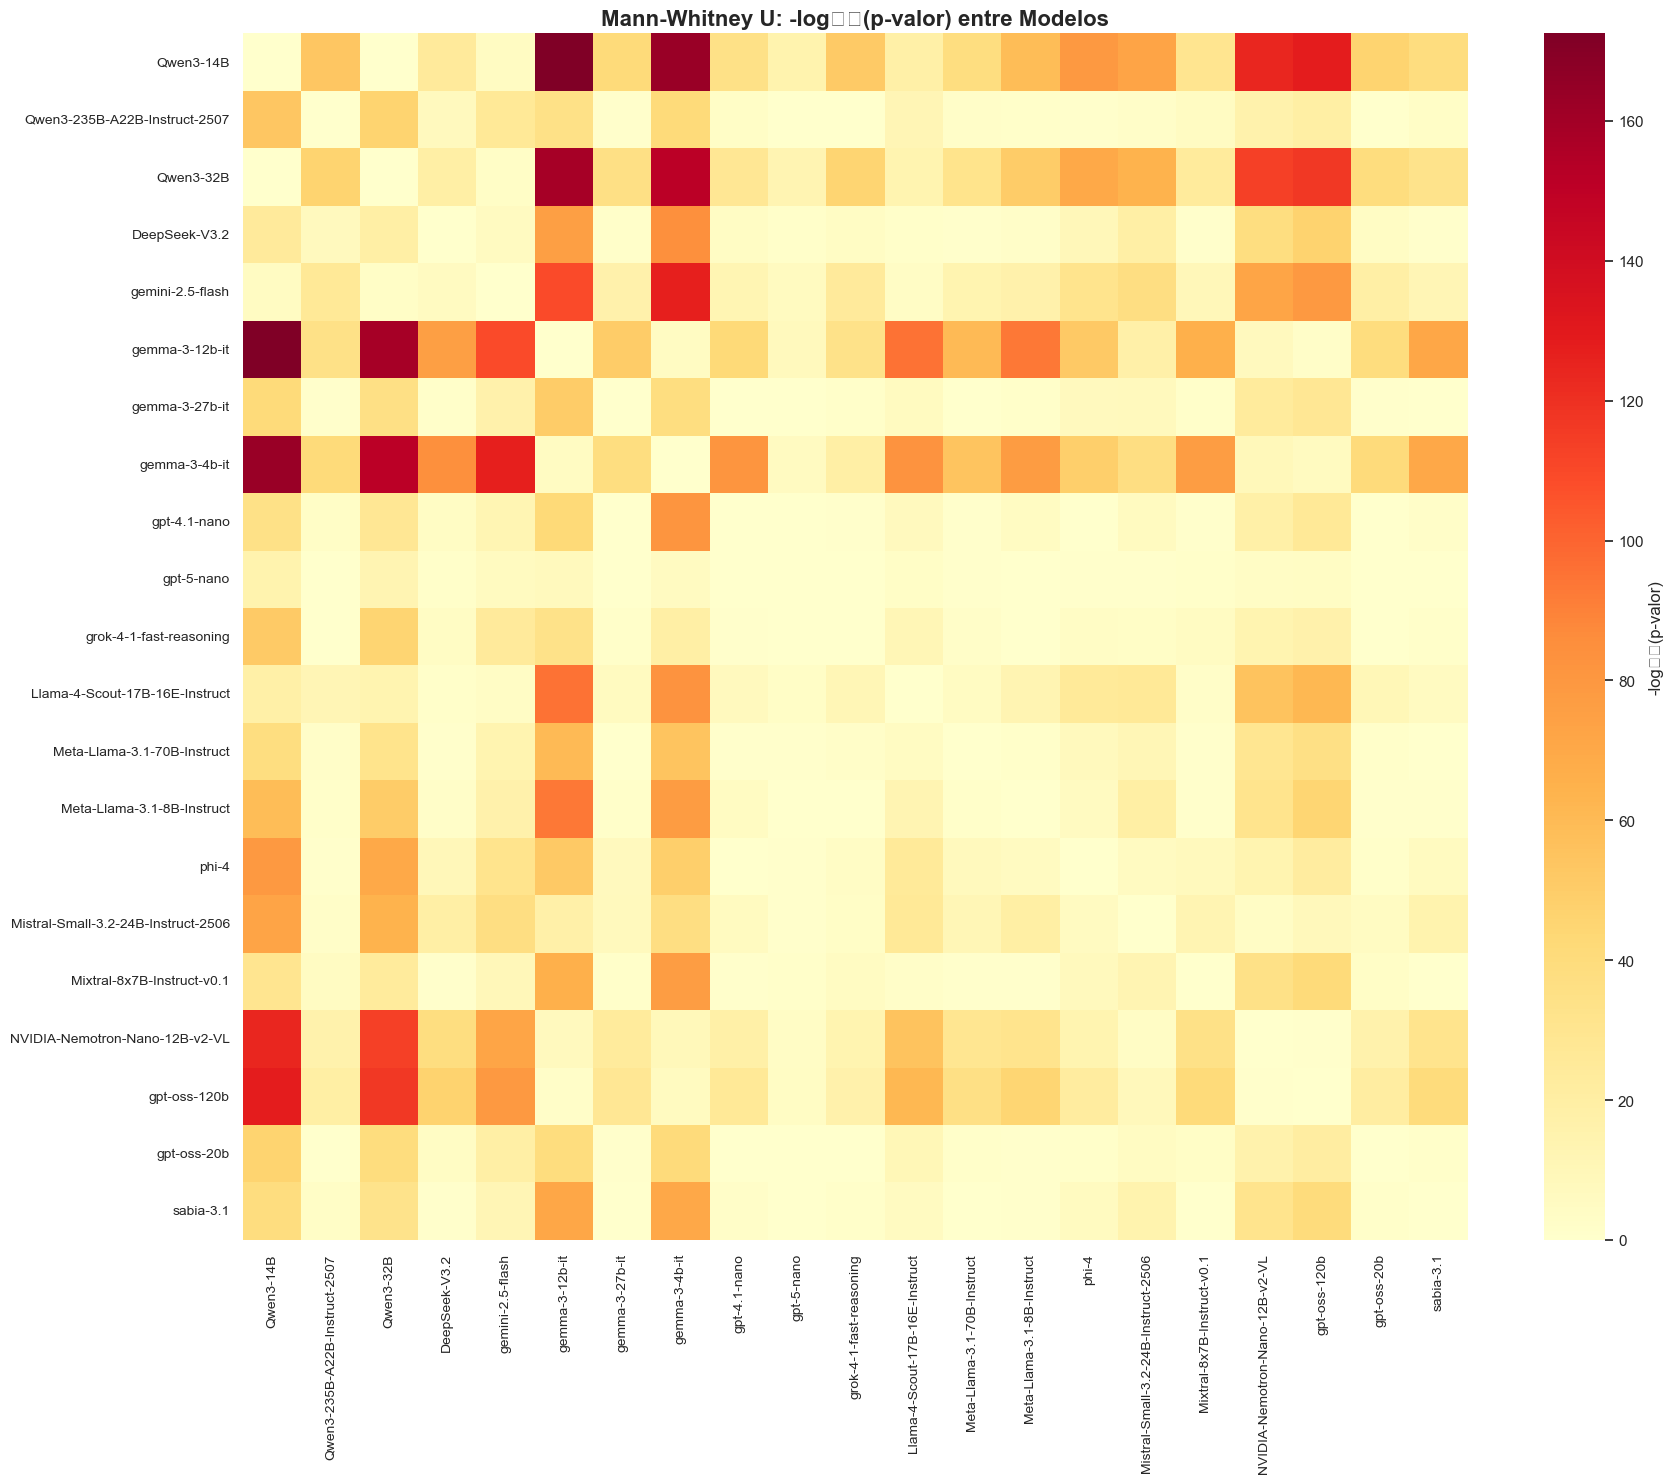

In [6]:
# Wilcoxon rank-sum entre todos os pares de modelos (1 a 1)
print("=" * 70)
print("MANN-WHITNEY U — TODAS AS COMPARAÇÕES MODELO A MODELO")
print("=" * 70)

all_models = sorted(df_validos['modelo'].unique())
n_models = len(all_models)
n_pairs = n_models * (n_models - 1) // 2
alpha_bonf_models = 0.05 / n_pairs
print(f"\n  {n_models} modelos → {n_pairs} comparações")
print(f"  Correção de Bonferroni: α_adj = {alpha_bonf_models:.6f}\n")

model_pair_results = []
for m1, m2 in combinations(all_models, 2):
    g1 = df_validos[df_validos['modelo'] == m1]['likert_score'].values
    g2 = df_validos[df_validos['modelo'] == m2]['likert_score'].values
    u_stat, u_p = mannwhitneyu(g1, g2, alternative='two-sided')
    n1, n2 = len(g1), len(g2)
    r_effect = 1 - (2 * u_stat) / (n1 * n2)
    
    model_pair_results.append({
        'Modelo 1': m1.split('/')[-1],
        'Modelo 2': m2.split('/')[-1],
        'Role 1': assign_role(m1),
        'Role 2': assign_role(m2),
        'U': u_stat,
        'p-valor': u_p,
        'r': round(r_effect, 4),
        'Sig. (Bonf.)': "SIM" if u_p < alpha_bonf_models else "NÃO",
    })

df_model_pairs = pd.DataFrame(model_pair_results)

# Mostrar apenas as significativas primeiro
sig_pairs = df_model_pairs[df_model_pairs['Sig. (Bonf.)'] == 'SIM']
print(f"  Pares significativos após Bonferroni: {len(sig_pairs)} / {n_pairs}\n")

# Mostrar top 20 por menor p-valor
display(df_model_pairs.sort_values('p-valor').head(20))

# Heatmap de p-valores
p_matrix = pd.DataFrame(np.ones((n_models, n_models)), 
                         index=[m.split('/')[-1] for m in all_models],
                         columns=[m.split('/')[-1] for m in all_models])
for _, row in df_model_pairs.iterrows():
    p_matrix.loc[row['Modelo 1'], row['Modelo 2']] = row['p-valor']
    p_matrix.loc[row['Modelo 2'], row['Modelo 1']] = row['p-valor']

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(-np.log10(p_matrix.astype(float)), 
            annot=False, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': '-log₁₀(p-valor)'})
ax.set_title('Mann-Whitney U: -log₁₀(p-valor) entre Modelos', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.show()

## 5. Teste de Friedman

Teste para medidas repetidas / blocos relacionados. Aqui tratamos cada **pair_id** (par de afirmações) como bloco e a resposta média de cada grupo como a medida repetida.

$H_0$: As medianas dos scores Likert são iguais nos 3 grupos (dentro de cada bloco).  
$H_1$: Pelo menos um grupo difere.

In [7]:
# Teste de Friedman — usando pair_id como bloco
print("=" * 70)
print("TESTE DE FRIEDMAN")
print("=" * 70)

# Para o Friedman, precisamos de medidas pareadas por bloco.
# Usamos pair_id como bloco: para cada pair_id, calculamos a média
# do likert_score de cada grupo.
df_friedman = (
    df_validos.groupby(['pair_id', 'role'])['likert_score']
    .mean()
    .reset_index()
    .pivot(index='pair_id', columns='role', values='likert_score')
    .dropna()  # apenas blocos com dados nos 3 grupos
)
df_friedman = df_friedman[GROUP_ORDER]

print(f"\n  Blocos (pair_ids) com dados nos 3 grupos: {len(df_friedman)}")
print(f"  Colunas: {list(df_friedman.columns)}\n")

# Friedman test
friedman_stat, friedman_p = friedmanchisquare(
    df_friedman[GROUP_ORDER[0]].values,
    df_friedman[GROUP_ORDER[1]].values,
    df_friedman[GROUP_ORDER[2]].values,
)

# Kendall's W (efeito): W = χ² / (N * (k-1))
k = len(GROUP_ORDER)
N_blocks = len(df_friedman)
kendall_w = friedman_stat / (N_blocks * (k - 1))

print(f"  Estatística χ² = {friedman_stat:.4f}")
print(f"  p-valor        = {friedman_p:.2e}")
print(f"  Kendall's W    = {kendall_w:.6f}")
print(f"\n  Interpretação: {'SIGNIFICATIVO' if friedman_p < 0.05 else 'Não significativo'} (α = 0.05)")

# Post-hoc Wilcoxon signed-rank (pareado) se Friedman for significativo
if friedman_p < 0.05:
    print("\n  → Friedman significativo. Post-hoc com Wilcoxon signed-rank pareado:\n")
    alpha_bonf_fr = 0.05 / 3
    
    posthoc_results = []
    for r1, r2 in combinations(GROUP_ORDER, 2):
        w_stat, w_p = wilcoxon(
            df_friedman[r1].values,
            df_friedman[r2].values,
            alternative='two-sided',
        )
        sig = "SIM" if w_p < alpha_bonf_fr else "NÃO"
        posthoc_results.append({
            'Grupo 1': r1,
            'Grupo 2': r2,
            'W': w_stat,
            'p-valor': w_p,
            'Sig. (Bonf. α=0.0167)': sig,
        })
        print(f"    {r1} vs {r2}: W={w_stat:.0f}, p={w_p:.2e} → {'SIG' if w_p < alpha_bonf_fr else 'n.s.'}")
    
    df_posthoc_friedman = pd.DataFrame(posthoc_results)
    display(df_posthoc_friedman)
else:
    print("\n  → Friedman não significativo. Não é necessário post-hoc.")

TESTE DE FRIEDMAN

  Blocos (pair_ids) com dados nos 3 grupos: 56
  Colunas: ['Pair Generators', 'Judge Models', 'Pure Respondents']

  Estatística χ² = 11.3274
  p-valor        = 3.47e-03
  Kendall's W    = 0.101137

  Interpretação: SIGNIFICATIVO (α = 0.05)

  → Friedman significativo. Post-hoc com Wilcoxon signed-rank pareado:

    Pair Generators vs Judge Models: W=426, p=3.90e-03 → SIG
    Pair Generators vs Pure Respondents: W=786, p=9.22e-01 → n.s.
    Judge Models vs Pure Respondents: W=379, p=6.31e-04 → SIG


,Grupo 1,Grupo 2,W,p-valor,Sig. (Bonf. α=0.0167)
0,Pair Generators,Judge Models,425.5,0.003896,SIM
1,Pair Generators,Pure Respondents,786.0,0.922024,NÃO
2,Judge Models,Pure Respondents,379.0,0.000631,SIM


## 5b. Post-hoc de Nemenyi (após Friedman)

Quando o Friedman é significativo, aplicamos o teste de Nemenyi para comparações múltiplas pareadas entre os grupos.

In [8]:
# Post-hoc de Nemenyi para dados em blocos (Friedman)
import scikit_posthocs as sp

print("=" * 70)
print("POST-HOC DE NEMENYI (FRIEDMAN)")
print("=" * 70)

if friedman_p < 0.05:
    nemenyi_p = sp.posthoc_nemenyi_friedman(df_friedman[GROUP_ORDER])
    nemenyi_p = nemenyi_p.loc[GROUP_ORDER, GROUP_ORDER]

    print("\nMatriz de p-valores (Nemenyi):")
    display(nemenyi_p)

    alpha_nemenyi = 0.05
    print(f"\nComparações significativas (α = {alpha_nemenyi}):")
    found_sig = False
    for i, g1 in enumerate(GROUP_ORDER):
        for j, g2 in enumerate(GROUP_ORDER):
            if j <= i:
                continue
            p_val = nemenyi_p.loc[g1, g2]
            is_sig = p_val < alpha_nemenyi
            print(f"  {g1} vs {g2}: p = {p_val:.4e} -> {'SIGNIFICATIVO' if is_sig else 'não significativo'}")
            if is_sig:
                found_sig = True

    if not found_sig:
        print("  Nenhuma comparação par a par foi significativa no Nemenyi.")
else:
    print("Friedman não foi significativo; Nemenyi não é necessário.")

POST-HOC DE NEMENYI (FRIEDMAN)

Matriz de p-valores (Nemenyi):


,Pair Generators,Judge Models,Pure Respondents
Pair Generators,1.000000,0.012742,0.988986
Judge Models,0.012742,1.000000,0.008202
Pure Respondents,0.988986,0.008202,1.000000



Comparações significativas (α = 0.05):
  Pair Generators vs Judge Models: p = 1.2742e-02 -> SIGNIFICATIVO
  Pair Generators vs Pure Respondents: p = 9.8899e-01 -> não significativo
  Judge Models vs Pure Respondents: p = 8.2015e-03 -> SIGNIFICATIVO


## 5c. Friedman + Nemenyi com **todos os modelos**

Aqui cada modelo é um tratamento no Friedman (blocos = `pair_id`). Se o teste for significativo, aplicamos Nemenyi entre todos os modelos e exibimos o diagrama de diferença crítica (CD).

FRIEDMAN + NEMENYI (TODOS OS MODELOS)

Blocos completos: 56
Modelos no Friedman: 21

Friedman χ² = 569.8637
p-valor     = 6.35e-108
Kendall's W = 0.508807

→ Friedman significativo. Aplicando Nemenyi em todos os pares de modelos.

Pares com diferença significativa: 116 / 210


,Modelo 1,Modelo 2,p-valor (Nemenyi),Diferem?
122,google/gemma-3-4b-it,meta-llama/Llama-4-Scout-17B-16E-Instruct,1.110223e-16,SIM
16,Qwen/Qwen3-14B,nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL,1.110223e-16,SIM
86,google/gemini-2.5-flash,nvidia/NVIDIA-Nemotron-Nano-12B-v2-VL,1.110223e-16,SIM
76,google/gemini-2.5-flash,google/gemma-3-4b-it,1.110223e-16,SIM
74,google/gemini-2.5-flash,google/gemma-3-12b-it,1.110223e-16,SIM
124,google/gemma-3-4b-it,meta-llama/Meta-Llama-3.1-8B-Instruct,1.110223e-16,SIM
60,deepseek-ai/DeepSeek-V3.2,google/gemma-3-4b-it,1.110223e-16,SIM
87,google/gemini-2.5-flash,openai/gpt-oss-120b,1.110223e-16,SIM
17,Qwen/Qwen3-14B,openai/gpt-oss-120b,1.110223e-16,SIM
97,google/gemma-3-12b-it,meta-llama/Meta-Llama-3.1-8B-Instruct,1.110223e-16,SIM



Subgrupos mutuamente não diferentes (cliques máximas, Nemenyi p >= 0.05):
  Grupo 1 (10 modelos): Qwen3-14B, Qwen3-32B, DeepSeek-V3.2, gemini-2.5-flash, gpt-4.1-nano, Llama-4-Scout-17B-16E-Instruct, Meta-Llama-3.1-8B-Instruct, phi-4, Mixtral-8x7B-Instruct-v0.1, sabia-3.1
  Grupo 2 (8 modelos): DeepSeek-V3.2, gpt-4.1-nano, Llama-4-Scout-17B-16E-Instruct, Meta-Llama-3.1-70B-Instruct, Meta-Llama-3.1-8B-Instruct, phi-4, Mixtral-8x7B-Instruct-v0.1, sabia-3.1
  Grupo 3 (7 modelos): Qwen3-235B-A22B-Instruct-2507, gemma-3-27b-it, gpt-5-nano, grok-4-1-fast-reasoning, Meta-Llama-3.1-70B-Instruct, Mistral-Small-3.2-24B-Instruct-2506, gpt-oss-20b
  Grupo 4 (6 modelos): gemma-3-27b-it, gpt-4.1-nano, Meta-Llama-3.1-70B-Instruct, phi-4, Mixtral-8x7B-Instruct-v0.1, gpt-oss-20b
  Grupo 5 (5 modelos): Qwen3-235B-A22B-Instruct-2507, gpt-5-nano, grok-4-1-fast-reasoning, Mistral-Small-3.2-24B-Instruct-2506, NVIDIA-Nemotron-Nano-12B-v2-VL
  Grupo 6 (5 modelos): gemma-3-12b-it, gpt-5-nano, grok-4-1-fast-rea

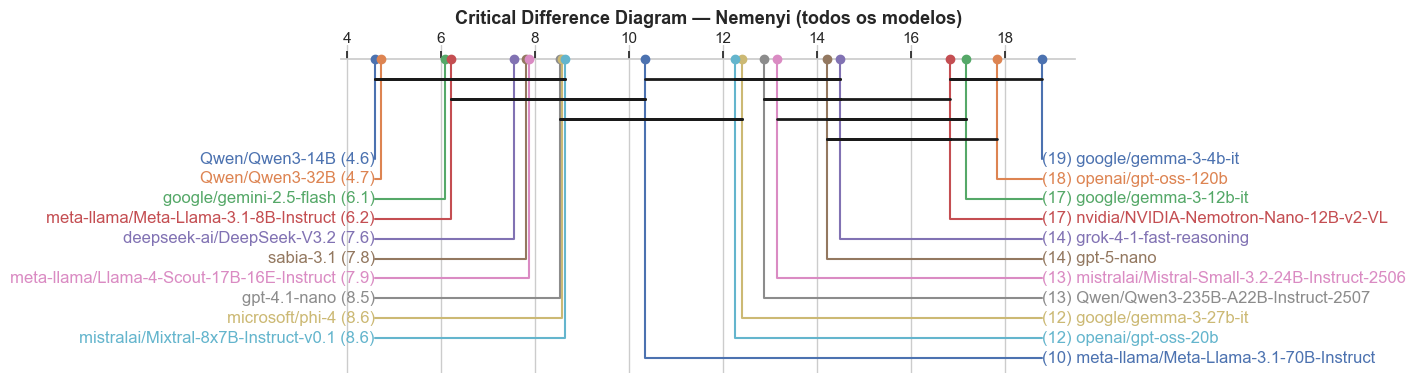

In [13]:
# Friedman + Nemenyi com TODOS os modelos (blocos = pair_id)
import scikit_posthocs as sp

print("=" * 70)
print("FRIEDMAN + NEMENYI (TODOS OS MODELOS)")
print("=" * 70)

alpha = 0.05

# Matriz bloco x modelo (média por pair_id/modelo)
df_friedman_models = (
    df_validos.groupby(['pair_id', 'modelo'])['likert_score']
    .mean()
    .reset_index()
    .pivot(index='pair_id', columns='modelo', values='likert_score')
    .dropna()
)

models_all = list(df_friedman_models.columns)
k_models = len(models_all)
n_blocks_models = len(df_friedman_models)

print(f"\nBlocos completos: {n_blocks_models}")
print(f"Modelos no Friedman: {k_models}")

friedman_inputs = [df_friedman_models[m].values for m in models_all]
friedman_models_stat, friedman_models_p = friedmanchisquare(*friedman_inputs)
kendall_w_models = friedman_models_stat / (n_blocks_models * (k_models - 1))

print(f"\nFriedman χ² = {friedman_models_stat:.4f}")
print(f"p-valor     = {friedman_models_p:.2e}")
print(f"Kendall's W = {kendall_w_models:.6f}")

if friedman_models_p < alpha:
    print("\n→ Friedman significativo. Aplicando Nemenyi em todos os pares de modelos.\n")

    nemenyi_models = sp.posthoc_nemenyi_friedman(df_friedman_models)
    nemenyi_models = nemenyi_models.loc[models_all, models_all]

    # Ranking médio por bloco (maior likert = melhor rank)
    avg_ranks = df_friedman_models.rank(axis=1, method='average', ascending=False).mean(axis=0)
    avg_ranks = avg_ranks.sort_values()

    # CD numérico (quando disponível)
    try:
        cd_value = sp.critical_difference(avg_ranks.values, n_blocks_models, alpha=0.05)
        print(f"CD (Nemenyi, α=0.05): {cd_value:.4f}\n")
    except Exception:
        pass

    # Pares significativos / não significativos
    sig_rows = []
    nonsig_graph = {m: set() for m in models_all}

    for i, m1 in enumerate(models_all):
        for j, m2 in enumerate(models_all):
            if j <= i:
                continue
            p_val = float(nemenyi_models.loc[m1, m2])
            is_sig = p_val < alpha
            sig_rows.append({
                'Modelo 1': m1,
                'Modelo 2': m2,
                'p-valor (Nemenyi)': p_val,
                'Diferem?': 'SIM' if is_sig else 'NÃO'
            })
            if not is_sig:
                nonsig_graph[m1].add(m2)
                nonsig_graph[m2].add(m1)

    df_nemenyi_pairs = pd.DataFrame(sig_rows).sort_values('p-valor (Nemenyi)')
    print(f"Pares com diferença significativa: {(df_nemenyi_pairs['Diferem?'] == 'SIM').sum()} / {len(df_nemenyi_pairs)}")
    display(df_nemenyi_pairs.head(30))

    # Cliques máximas de não-diferença (todos do grupo são mutuamente n.s.)
    def bron_kerbosch(r, p, x, graph, out):
        if not p and not x:
            out.append(set(r))
            return
        for v in list(p):
            bron_kerbosch(r | {v}, p & graph[v], x & graph[v], graph, out)
            p.remove(v)
            x.add(v)

    all_nodes = set(models_all)
    cliques = []
    bron_kerbosch(set(), set(all_nodes), set(), nonsig_graph, cliques)

    cliques = [c for c in cliques if len(c) >= 2]
    cliques = sorted(cliques, key=lambda c: (-len(c), sorted(c)))

    print("\nSubgrupos mutuamente não diferentes (cliques máximas, Nemenyi p >= 0.05):")
    if not cliques:
        print("  Nenhum subgrupo com 2+ modelos foi encontrado.")
    else:
        for idx, clique in enumerate(cliques[:15], start=1):
            labels = [m.split('/')[-1] for m in sorted(clique)]
            print(f"  Grupo {idx} ({len(clique)} modelos): {', '.join(labels)}")
        if len(cliques) > 15:
            print(f"  ... e mais {len(cliques) - 15} cliques.")

    # Diagrama de diferença crítica
    print("\nDiagrama de diferença crítica (CD):")
    try:
        fig, ax = plt.subplots(figsize=(14, 4))
        sp.critical_difference_diagram(avg_ranks, nemenyi_models, ax=ax)
        ax.set_title('Critical Difference Diagram — Nemenyi (todos os modelos)', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print(f"Não foi possível gerar o CD diagram automaticamente: {exc}")

else:
    print("\n→ Friedman não significativo para todos os modelos; Nemenyi não é necessário.")

In [10]:
# Interpretação prática do tamanho de efeito (Friedman)
print("=" * 70)
print("INTERPRETAÇÃO DO TAMANHO DE EFEITO")
print("=" * 70)

w = float(kendall_w)

if w < 0.1:
    w_label = "negligível"
elif w < 0.3:
    w_label = "pequeno"
elif w < 0.5:
    w_label = "moderado"
else:
    w_label = "grande"

print(f"\nKendall's W = {w:.4f}")
print(f"Classificação: efeito {w_label}")
print(f"Variância explicada aproximada: {w * 100:.2f}%")

if friedman_p < 0.05 and w < 0.3:
    print("\nConclusão: há diferença estatisticamente significativa entre grupos,")
    print("mas a magnitude prática dessa diferença é pequena.")

INTERPRETAÇÃO DO TAMANHO DE EFEITO

Kendall's W = 0.1011
Classificação: efeito pequeno
Variância explicada aproximada: 10.11%

Conclusão: há diferença estatisticamente significativa entre grupos,
mas a magnitude prática dessa diferença é pequena.


## 6. Visualização — Violin Plot (Figure 11)

Reprodução da figura 11: violinos por modelo, agrupados por papel no pipeline, com testes estatísticos.

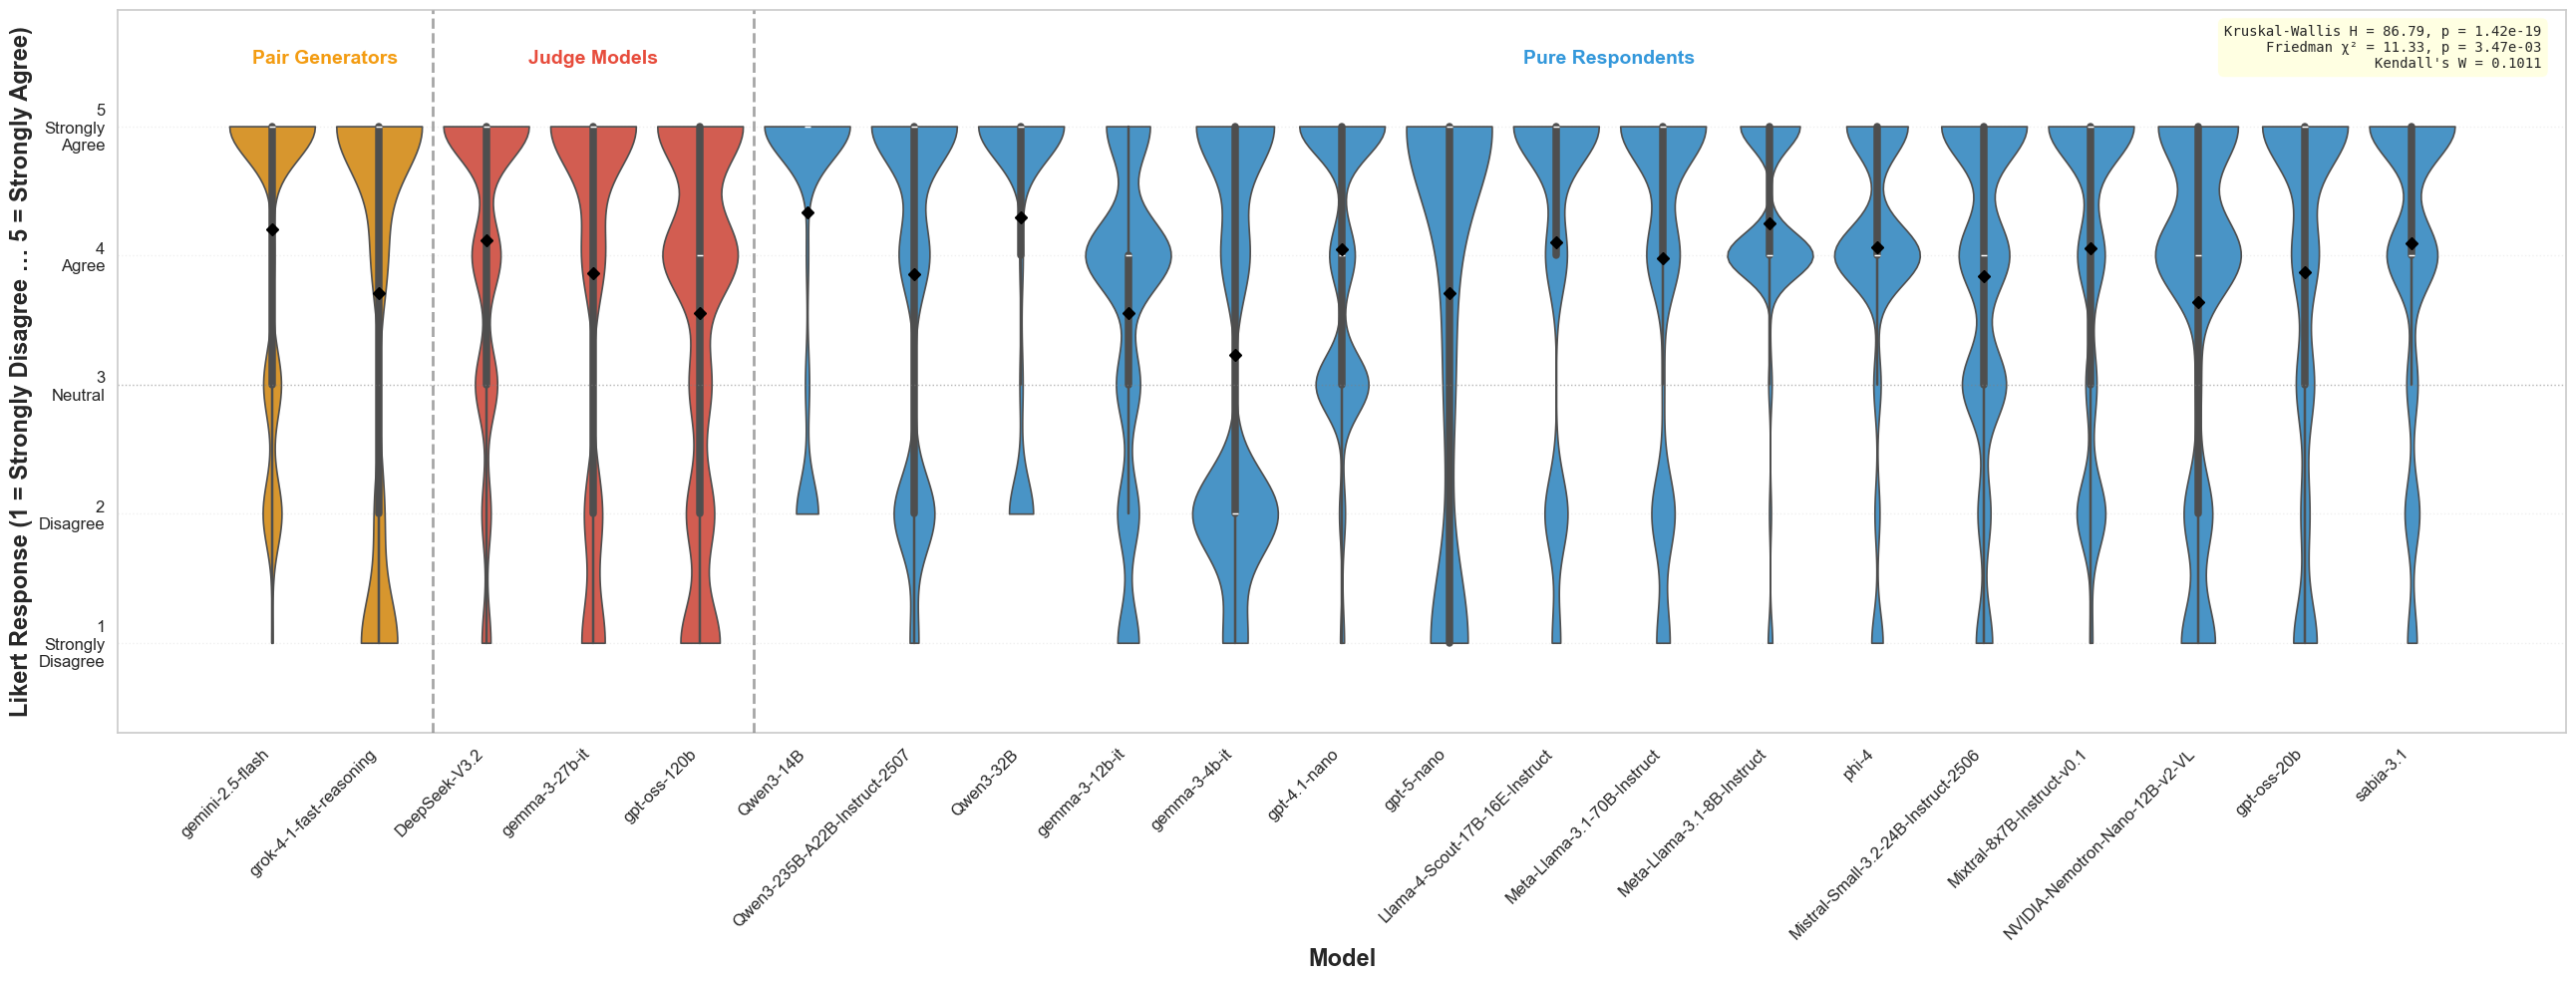

In [8]:
# Violin plot por modelo com separação de grupos
GROUP_PALETTE = {
    'Pair Generators': '#f39c12',
    'Judge Models': '#e74c3c',
    'Pure Respondents': '#3498db',
}

# Ordenar modelos por grupo
models_ordered = []
group_boundaries = []
for grp in GROUP_ORDER:
    grp_models = sorted(df_validos.loc[df_validos['role'] == grp, 'modelo'].unique())
    models_ordered.extend(grp_models)
    group_boundaries.append(len(models_ordered))

short_labels = [m.split('/')[-1] for m in models_ordered]
model_colors = [GROUP_PALETTE[assign_role(m)] for m in models_ordered]

df_validos['modelo_cat'] = pd.Categorical(df_validos['modelo'], categories=models_ordered, ordered=True)

fig, ax = plt.subplots(figsize=(26, 10))

sns.violinplot(
    data=df_validos, x='modelo_cat', y='likert_score',
    order=models_ordered, hue='modelo_cat', palette=model_colors,
    inner='box', cut=0, linewidth=1.2, ax=ax,
    density_norm='width', saturation=0.75, legend=False,
)

# Médias por modelo
for i, m in enumerate(models_ordered):
    mean_val = df_validos.loc[df_validos['modelo'] == m, 'likert_score'].mean()
    ax.plot(i, mean_val, marker='D', color='black', markersize=6, zorder=5)

# Linhas separadoras
for boundary in group_boundaries[:-1]:
    ax.axvline(x=boundary - 0.5, color='grey', linewidth=2, linestyle='--', alpha=0.7, zorder=4)

# Labels de grupo
prev = 0
for grp, boundary in zip(GROUP_ORDER, group_boundaries):
    mid = (prev + boundary - 1) / 2.0
    ax.text(mid, 5.45, grp, ha='center', va='bottom', fontsize=14, fontweight='bold',
            color=GROUP_PALETTE[grp])
    prev = boundary

# Annotation box com testes
stat_text = (
    f"Kruskal-Wallis H = {kw_stat:.2f}, p = {kw_p:.2e}\n"
    f"Friedman χ² = {friedman_stat:.2f}, p = {friedman_p:.2e}\n"
    f"Kendall's W = {kendall_w:.4f}"
)
ax.text(0.99, 0.98, stat_text, transform=ax.transAxes, fontsize=10,
        va='top', ha='right', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.92))

ax.set_xlabel('Model', fontsize=17, fontweight='bold')
ax.set_ylabel('Likert Response (1 = Strongly Disagree … 5 = Strongly Agree)',
              fontsize=17, fontweight='bold')
ax.set_xticks(range(len(models_ordered)))
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['1\nStrongly\nDisagree', '2\nDisagree', '3\nNeutral',
                    '4\nAgree', '5\nStrongly\nAgree'], fontsize=12)
ax.set_ylim(0.3, 5.9)
ax.grid(axis='y', alpha=0.3, linestyle=':')
ax.axhline(y=3, color='grey', linewidth=1, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Resumo Geral dos Testes

Tabela consolidada com todos os testes estatísticos realizados.

In [9]:
# Resumo consolidado
print("=" * 70)
print("RESUMO CONSOLIDADO DOS TESTES ESTATÍSTICOS")
print("=" * 70)

summary = [
    {'Teste': 'Kruskal-Wallis (3 grupos)', 'Estatística': f'H = {kw_stat:.4f}',
     'p-valor': f'{kw_p:.2e}', 'Efeito': f'ε² = {epsilon_sq:.6f}',
     'Significativo?': 'SIM' if kw_p < 0.05 else 'NÃO'},
    {'Teste': 'Friedman (blocos = pair_id)', 'Estatística': f'χ² = {friedman_stat:.4f}',
     'p-valor': f'{friedman_p:.2e}', 'Efeito': f"W = {kendall_w:.6f}",
     'Significativo?': 'SIM' if friedman_p < 0.05 else 'NÃO'},
]

# Adicionar pairwise dos grupos
for _, row in df_wilcoxon.iterrows():
    summary.append({
        'Teste': f"Mann-Whitney U: {row['Grupo 1']} vs {row['Grupo 2']}",
        'Estatística': f"U = {row['U']:.0f}",
        'p-valor': f"{row['p-valor']:.2e}",
        'Efeito': f"r = {row['r (rank-biserial)']:.4f} ({row['Efeito']})",
        'Significativo?': row['Sig. (Bonferroni)'],
    })

df_summary = pd.DataFrame(summary)
display(df_summary)

print("\n\nLegenda:")
print("  • Kruskal-Wallis: teste omnibus para 3+ grupos independentes")
print("  • Mann-Whitney U: post-hoc par a par (Wilcoxon rank-sum) com Bonferroni")
print("  • Friedman: teste para medidas repetidas/blocos com Kendall's W")
print("  • ε² < 0.01 = negligível, 0.01-0.06 = pequeno, 0.06-0.14 = médio, > 0.14 = grande")
print("  • |r| < 0.1 = negligível, 0.1-0.3 = pequeno, 0.3-0.5 = médio, > 0.5 = grande")

RESUMO CONSOLIDADO DOS TESTES ESTATÍSTICOS


,Teste,Estatística,p-valor,Efeito,Significativo?
0,Kruskal-Wallis (3 grupos),H = 86.7900,1.42e-19,ε² = 0.001833,SIM
1,Friedman (blocos = pair_id),χ² = 11.3274,3.47e-03,W = 0.101137,SIM
2,Mann-Whitney U: Pair Generators vs Judge Models,U = 18014879,5.36e-19,r = -0.0884 (negligível),SIM
3,Mann-Whitney U: Pair Generators vs Pure Respon...,U = 89513060,1.03e-16,r = -0.0689 (negligível),SIM
4,Mann-Whitney U: Judge Models vs Pure Respondents,U = 122471690,1.45e-03,r = 0.0224 (negligível),SIM




Legenda:
  • Kruskal-Wallis: teste omnibus para 3+ grupos independentes
  • Mann-Whitney U: post-hoc par a par (Wilcoxon rank-sum) com Bonferroni
  • Friedman: teste para medidas repetidas/blocos com Kendall's W
  • ε² < 0.01 = negligível, 0.01-0.06 = pequeno, 0.06-0.14 = médio, > 0.14 = grande
  • |r| < 0.1 = negligível, 0.1-0.3 = pequeno, 0.3-0.5 = médio, > 0.5 = grande


# Especial Figures

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
from src.analysis import processing
df_resultados = pd.read_csv("dados/respostas_finais.csv")
likert_map = dict({
        "Concordo fortemente": 2,
        "Concordo": 1,
        "Neutro": 0,
        "Discordo": -1,
        "Discordo fortemente": -2
})
df_resultados['pontuacao'] = df_resultados['resposta_raw'].map(likert_map)
df_validos = df_resultados.dropna(subset=['pontuacao']).copy()
df_validos['pontuacao'] = df_validos['pontuacao'].astype(int)
# df_validos = df_validos[df_validos['pair_id'] == 0].copy()
df_pares, df_ip = processing.calcular_indice_polarizacao(df_validos)

In [39]:
df_validos.head(1)

,modelo,eixo,tipo_pergunta,pergunta,temperatura,repeticao,tendencia,pair_id,resposta_raw,pontuacao
0,sabia-3.1,Políticas Sociais,P+,"O Bolsa Família, embora possa ter um papel eme...",0.0,1,esquerda,0,Neutro,0


In [54]:
# tipo_pergunta = P+ e tendencia = esquerda
df_validos_teste = df_validos[(df_validos['tipo_pergunta'] == 'P+') & (df_validos['tendencia'] == 'esquerda')]
df_validos_teste.value_counts("pontuacao")

pontuacao
-1    66
 1    22
 0    19
-2    17
 2    17
Name: count, dtype: int64

In [38]:
# Taxa de concordância por tendência e tipo de pergunta
df_concordancia = df_validos.groupby(['tendencia', 'tipo_pergunta']).apply(
    lambda x: (x['pontuacao'] > 0).sum() / len(x) * 100
).reset_index()
df_concordancia.columns = ['tendencia', 'tipo_pergunta', 'taxa_concordancia_%']

# Pivot para visualização melhor
df_concordancia_pivot = df_concordancia.pivot(
    index='tendencia', 
    columns='tipo_pergunta', 
    values='taxa_concordancia_%'
)

display(df_concordancia_pivot.round(2))

/var/folders/8b/76sgx_zs6013gscxhhs5mxm80000gn/T/ipykernel_14465/1823037460.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_concordancia = df_validos.groupby(['tendencia', 'tipo_pergunta']).apply(


tipo_pergunta,P+,P-
tendencia,,
direita,95.04,34.75
esquerda,27.66,100.00
neutro,82.27,92.91


In [29]:
df_shifts = (
    df_ip.groupby(['modelo', 'tendencia'])['indice_polarizacao']
    .agg(['mean', 'std'])
    .reset_index()
)
df_shifts.columns = ['modelo', 'tendencia', 'ip_mean', 'ip_std']

df_pivot_mean = df_shifts.pivot(index='modelo', columns='tendencia', values='ip_mean').reset_index()
df_pivot_std = df_shifts.pivot(index='modelo', columns='tendencia', values='ip_std').reset_index()
df_pivot_std.columns = ['modelo', 'esquerda_std', 'neutro_std', 'direita_std']
df_pivot = df_pivot_mean.merge(df_pivot_std, on='modelo')

# Shifts em relação ao neutro
df_pivot['shift_left'] = (df_pivot['esquerda'] - df_pivot['neutro']).abs()
df_pivot['shift_right'] = (df_pivot['direita'] - df_pivot['neutro']).abs()
df_pivot['chameleon_index'] = df_pivot['shift_left'] + df_pivot['shift_right']

# Ordenações
df_pivot_a = df_pivot.sort_values('neutro').reset_index(drop=True)
y_pos = np.arange(len(df_pivot_a))

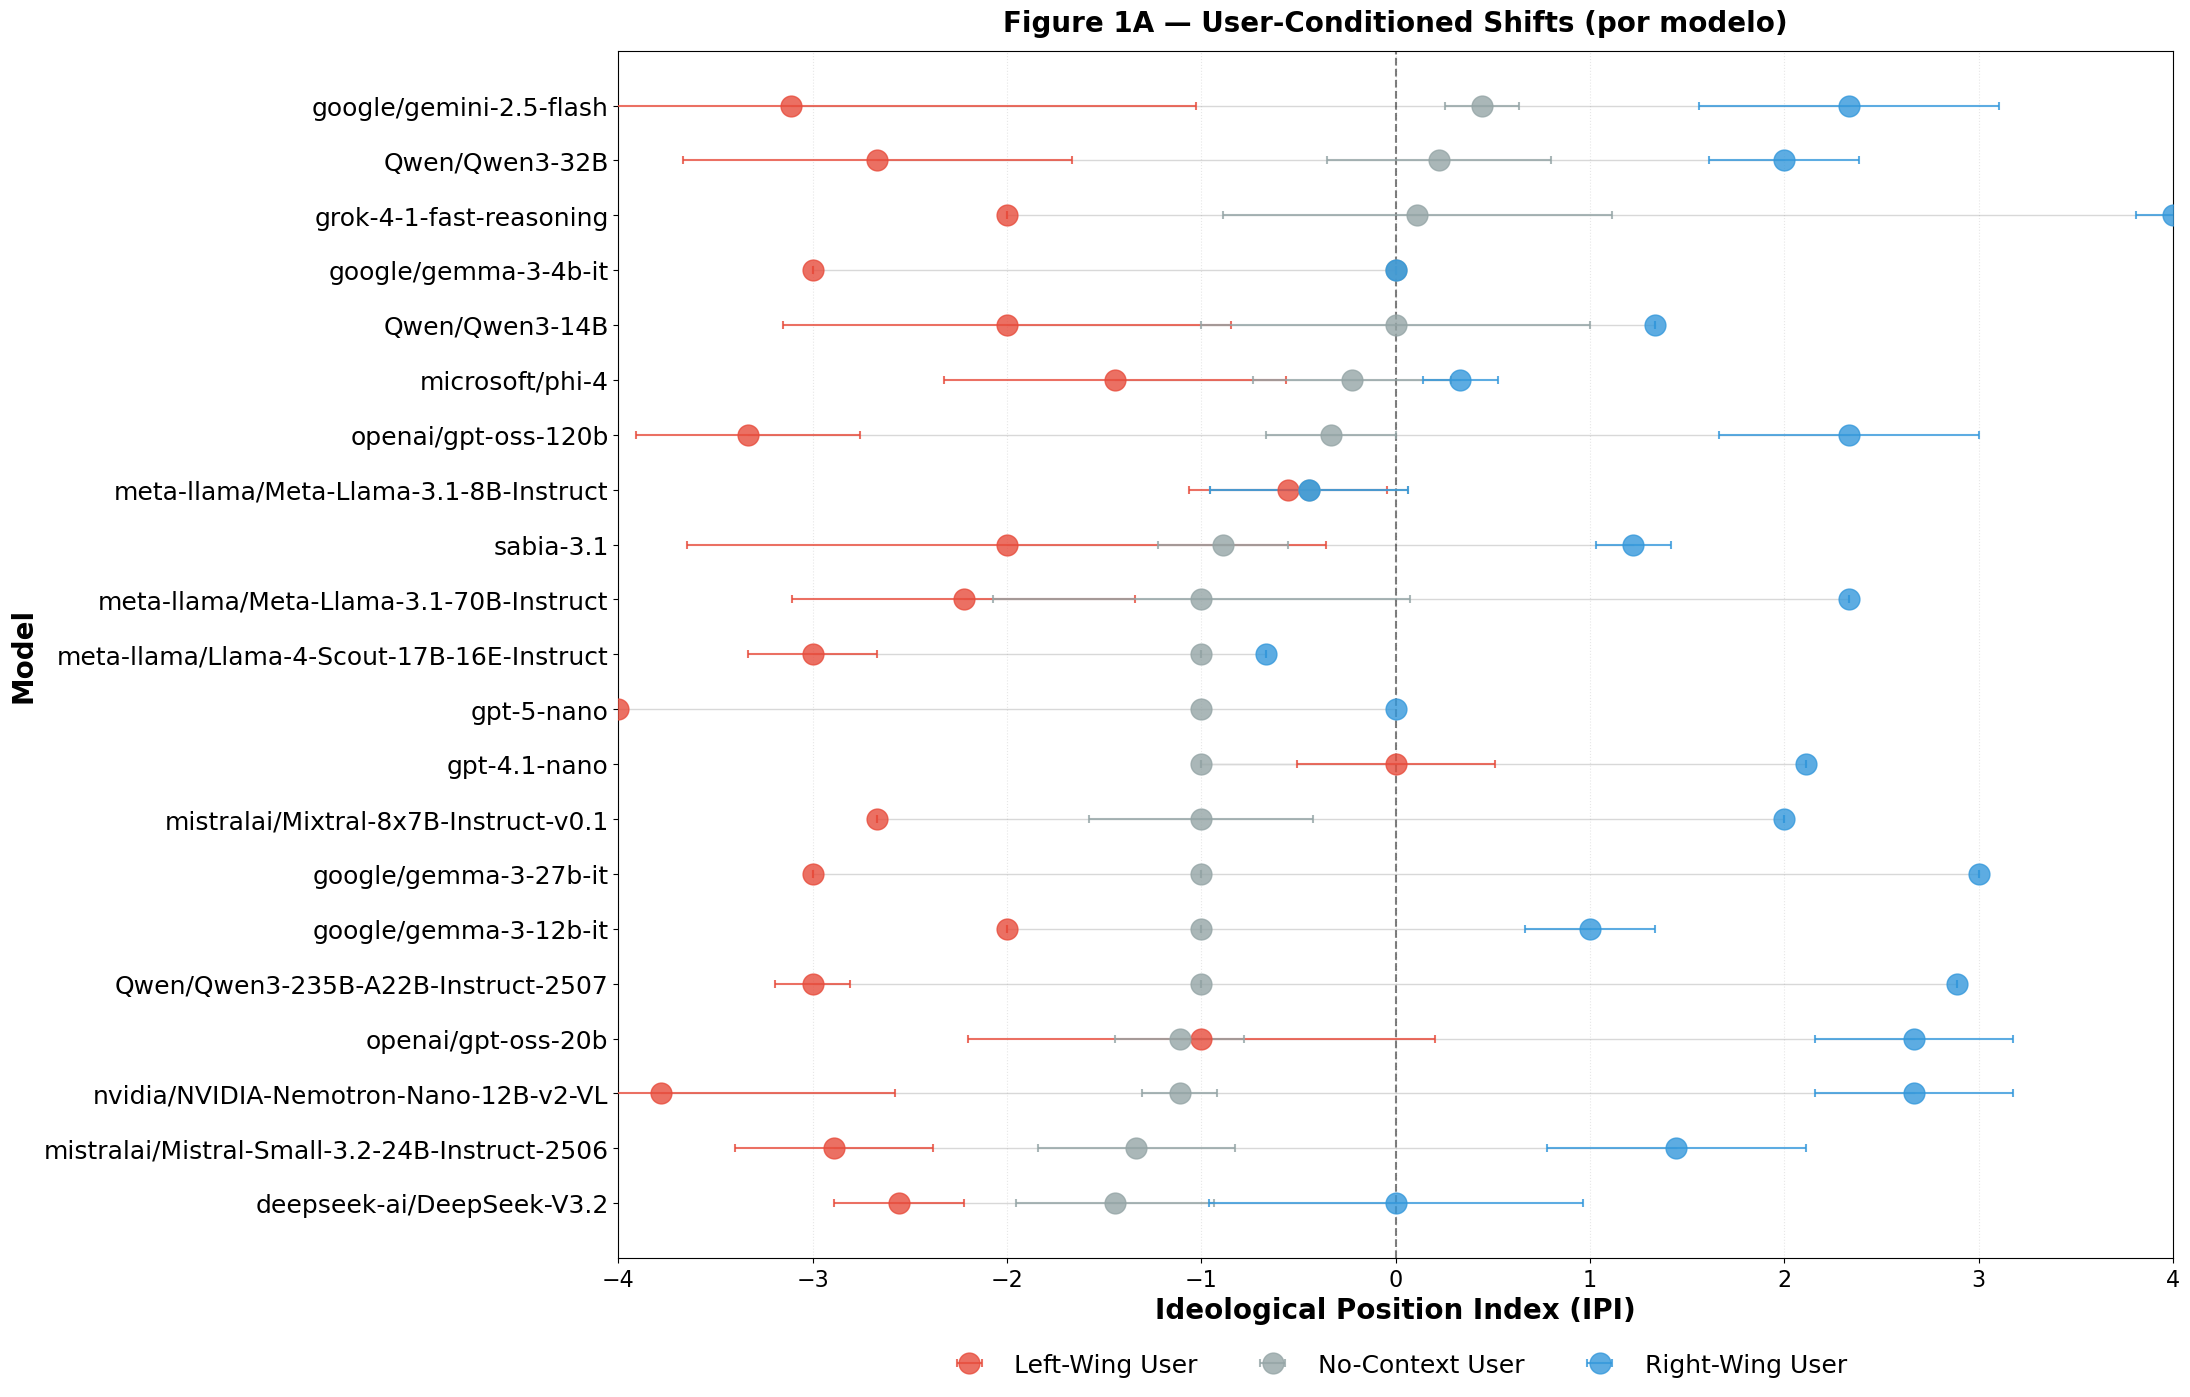

In [30]:
# --- somente o painel) ---
fig, ax = plt.subplots(figsize=(22, 14))
for row_idx, row in df_pivot_a.iterrows():
    x_values = [row['esquerda'], row['neutro'], row['direita']]
    ax.plot(x_values, [y_pos[row_idx]] * 3, color='gray', alpha=0.3, linewidth=1)

ax.errorbar(
    df_pivot_a['esquerda'], y_pos, xerr=df_pivot_a['esquerda_std'],
    fmt='o', markersize=15, color='#e74c3c', ecolor='#e74c3c',
    alpha=0.8, label='Left-Wing User', zorder=3, capsize=3, capthick=1.5,
)
ax.errorbar(
    df_pivot_a['neutro'], y_pos, xerr=df_pivot_a['neutro_std'],
    fmt='o', markersize=15, color='#95a5a6', ecolor='#95a5a6',
    alpha=0.8, label='No-Context User', zorder=3, capsize=3, capthick=1.5,
)
ax.errorbar(
    df_pivot_a['direita'], y_pos, xerr=df_pivot_a['direita_std'],
    fmt='o', markersize=15, color='#3498db', ecolor='#3498db',
    alpha=0.8, label='Right-Wing User', zorder=3, capsize=3, capthick=1.5,
)

ax.axvline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_pivot_a['modelo'], fontsize=18)
ax.set_xlabel('Ideological Position Index (IPI)', fontsize=20, fontweight='bold')
ax.set_ylabel('Model', fontsize=20, fontweight='bold')
ax.tick_params(axis='x', labelsize=16)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.06), fontsize=18, ncol=3, frameon=False)
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.set_xlim(-4, 4)
ax.set_title('Figure 1A — User-Conditioned Shifts (por modelo)', fontsize=20, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()
plt.close(fig)

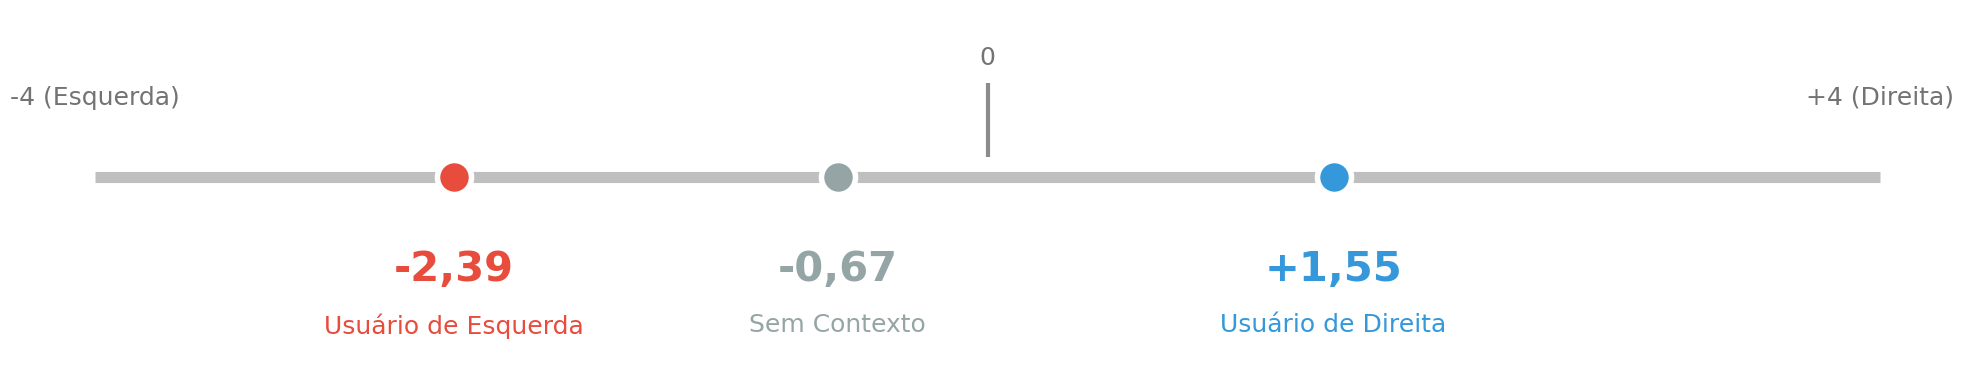

In [58]:
# --- Figura 1B (média dos modelos do painel A; estilo slide) ---
# Média não ponderada (cada modelo contribui igualmente) das médias por condição
cond_cols = ['esquerda', 'neutro', 'direita']
mean_by_cond = df_pivot[cond_cols].mean(axis=0)

def fmt_pt(value: float) -> str:
    if abs(value) < 5e-4:
        value = 0.0
    s = f"{value:+.2f}" if value > 0 else f"{value:.2f}"
    return s.replace('.', ',')

points = [
    ('Usuário de Esquerda', 'esquerda', '#e74c3c'),
    ('Sem Contexto', 'neutro', '#95a5a6'),
    ('Usuário de Direita', 'direita', '#3498db'),
]

fig2, ax2 = plt.subplots(figsize=(20, 3.8))
y0 = 0.0

# Linha base grossa de -4 a +4
ax2.hlines(y0, -4, 4, color='0.75', linewidth=8, zorder=1)

# Marcadores grandes + textos (sem legenda/título)
for label, key, color in points:
    x = float(mean_by_cond[key])
    ax2.scatter(
        [x], [y0],
        s=600, color=color, edgecolor='white', linewidth=4, zorder=3,
    )
    ax2.text(
        x, y0 - 0.22, fmt_pt(x),
        color=color, fontsize=30, fontweight='bold', ha='center', va='top',
    )
    ax2.text(
        x, y0 - 0.41, label,
        color=color, fontsize=18, ha='center', va='top',
    )

# Tick de 0 e rótulos de extremidade (como referência)
ax2.vlines(0, y0 + 0.06, y0 + 0.28, color='0.55', linewidth=3, zorder=2)
ax2.text(0, y0 + 0.32, '0', color='0.45', fontsize=18, ha='center', va='bottom')
ax2.text(-4, y0 + 0.20, '-4 (Esquerda)', color='0.45', fontsize=18, ha='center', va='bottom')
ax2.text(4, y0 + 0.20, '+4 (Direita)', color='0.45', fontsize=18, ha='center', va='bottom')

# Limpeza para visual “slide”
ax2.set_xlim(-4.3, 4.3)
ax2.set_ylim(-0.55, 0.50)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.grid(False)
for spine in ax2.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
plt.close(fig2)

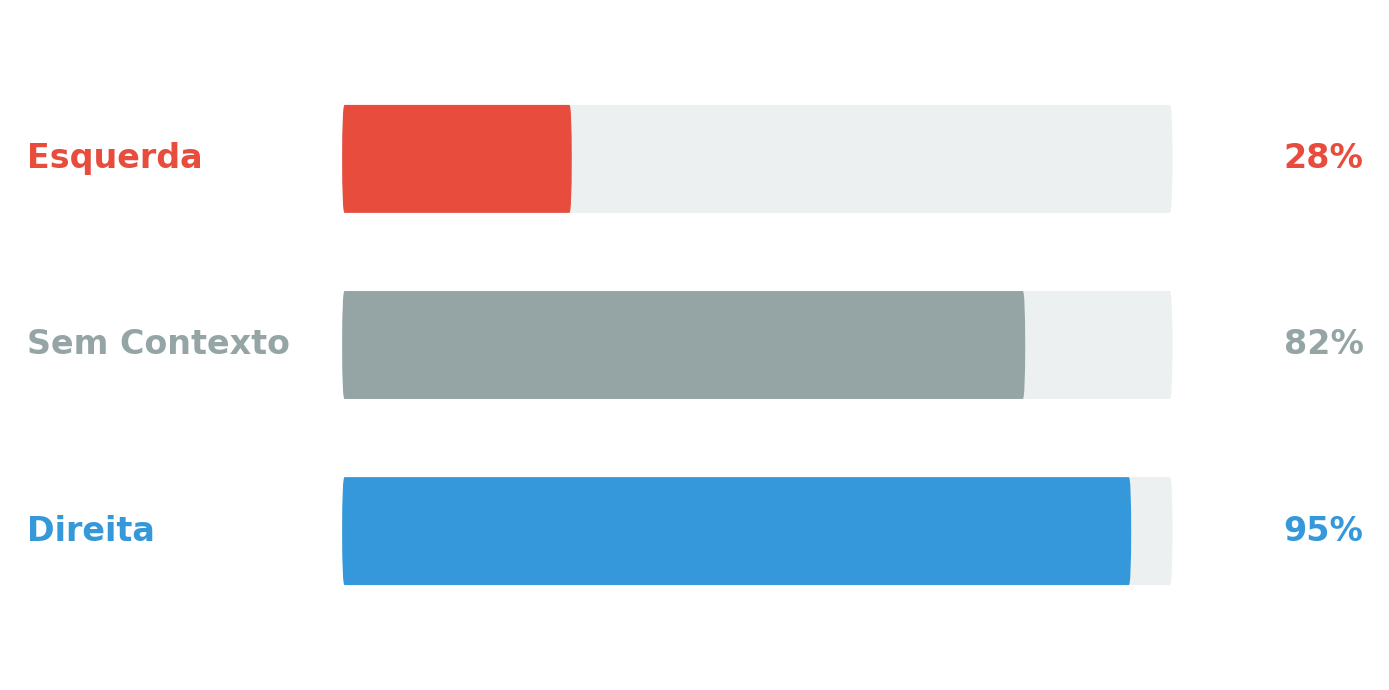

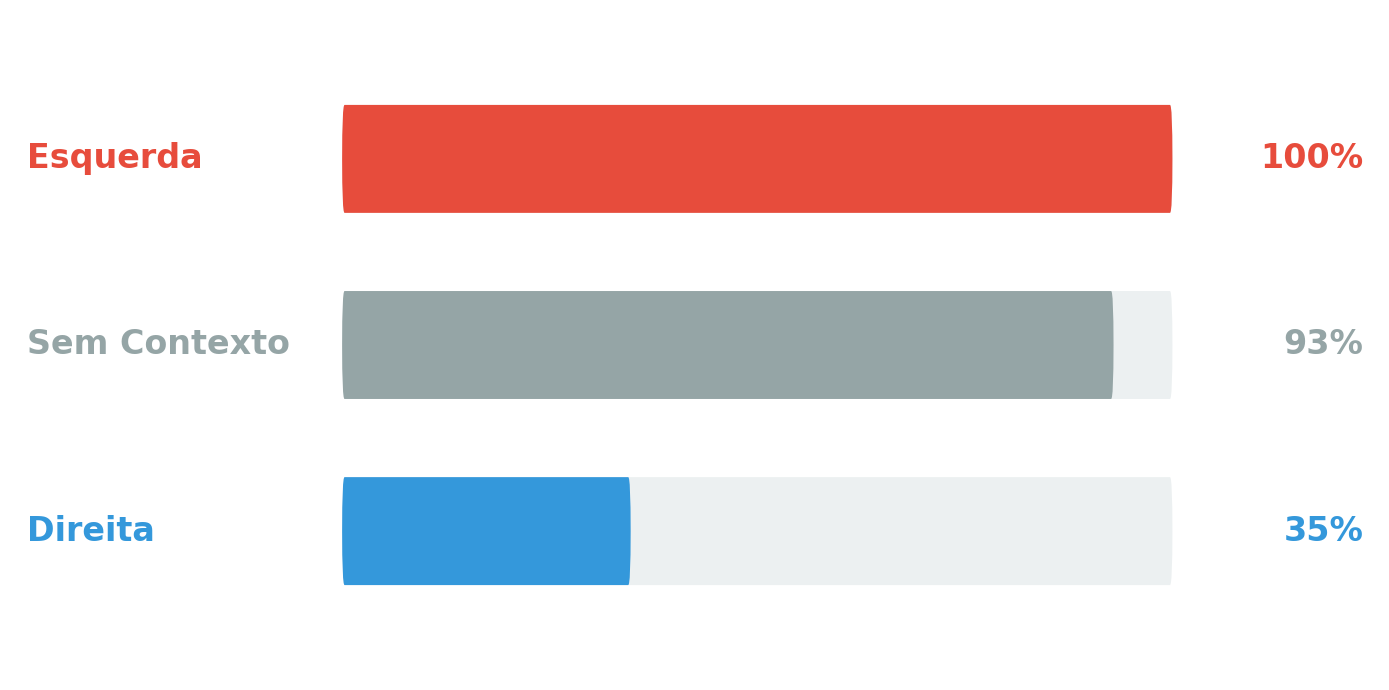

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# Gráfico estilo slide, inspirado na referência visual
def _find_col(df: pd.DataFrame, targets: list[str]):
    cols = list(df.columns)
    norm = {c: str(c).strip().lower() for c in cols}
    # match exato
    for t in targets:
        tnorm = str(t).strip().lower()
        for c, n in norm.items():
            if n == tnorm:
                return c
    # match por substring
    for t in targets:
        tnorm = str(t).strip().lower()
        for c, n in norm.items():
            if tnorm in n:
                return c
    return None

def _get_index_like(df: pd.DataFrame, candidates: list[str]):
    idx_map = {str(i).strip().lower(): i for i in df.index}
    for cand in candidates:
        key = str(cand).strip().lower()
        if key in idx_map:
            return idx_map[key]
    # tenta contains
    for cand in candidates:
        key = str(cand).strip().lower()
        for idx_norm, idx_real in idx_map.items():
            if key in idx_norm:
                return idx_real
    return None

def plot_concordancia_slide(df_pivot: pd.DataFrame, col, *, title: str):
    # Ordem e estilo (cores consistentes com o restante do notebook)
    rows = [
        ('Esquerda', ['esquerda'], '#e74c3c', True),
        ('Sem Contexto', ['neutro', 'sem contexto', 'sem_contexto', 'no-context'], '#95a5a6', True),
        ('Direita', ['direita'], '#3498db', True),
    ]
    values = []
    for _, idx_candidates, _, _ in rows:
        idx_real = _get_index_like(df_pivot, idx_candidates)
        if idx_real is None:
            values.append(np.nan)
        else:
            values.append(float(df_pivot.loc[idx_real, col]))
    
    fig, ax = plt.subplots(figsize=(14, 7))
    y_positions = [2, 1, 0]
    bar_h = 0.58
    bg_color = '#ecf0f1'
    
    def rounded_bar(x, y_center, width, height, color, z):
        patch = FancyBboxPatch(
            (x, y_center - height / 2),
            width, height,
            boxstyle=f"round,pad=0,rounding_size={height/2}",
            linewidth=0, facecolor=color, zorder=z,
        )
        ax.add_patch(patch)
    
    # Espaço extra à esquerda (labels) e à direita (percentuais)
    ax.set_xlim(-40, 125)
    ax.set_ylim(-0.8, 2.8)
    
    # Título (como na referência)
    ax.text(42.5, 2.55, title, fontsize=22, fontweight='bold', color='0.35', ha='center', va='center')
    
    for (label, _, color, bold), y, val in zip(rows, y_positions, values):
        # fundo 100%
        rounded_bar(0, y, 100, bar_h, bg_color, z=1)
        # preenchimento
        if not np.isnan(val):
            fill = max(0.0, min(100.0, float(val)))
            rounded_bar(0, y, fill, bar_h, color, z=2)
            pct_txt = f"{int(round(val))}%"
        else:
            pct_txt = "—"
        
        ax.text(-38, y, label, fontsize=24, fontweight=('bold' if bold else 'normal'), color=color, ha='left', va='center')
        ax.text(123, y, pct_txt, fontsize=24, fontweight='bold', color=color, ha='right', va='center')
    
    # Visual limpo (slide)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Detectar colunas P+ / P- (ou equivalentes)
col_p_plus = _find_col(df_concordancia_pivot, ['p+', 'p_plus', 'pmais', 'positivo'])
col_p_minus = _find_col(df_concordancia_pivot, ['p-', 'p_minus', 'pmenos', 'negativo'])

if col_p_plus is None or col_p_minus is None:
    print('Não consegui identificar automaticamente P+ / P- nas colunas:')
    print(df_concordancia_pivot.columns.tolist())
else:
    # Duas imagens separadas: P+ e P-
    plot_concordancia_slide(df_concordancia_pivot, col_p_plus, title='')
    plot_concordancia_slide(df_concordancia_pivot, col_p_minus, title='')

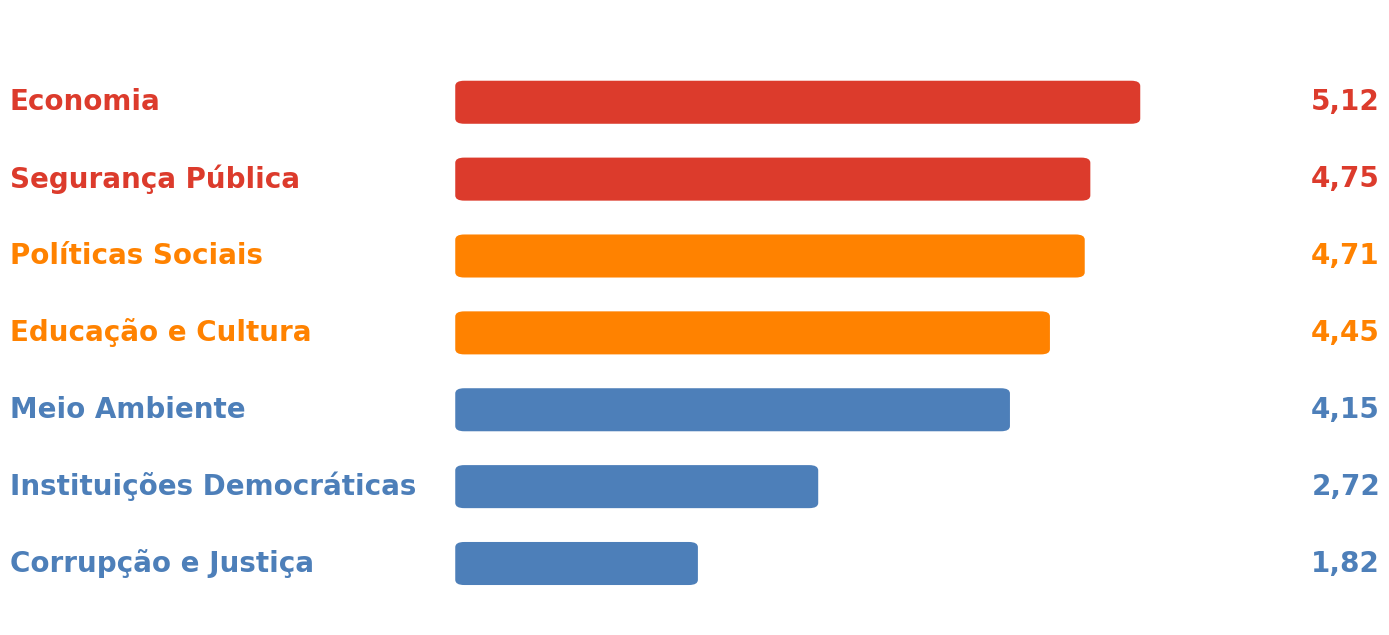

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import matplotlib as mpl

# Média dos modelos por categoria (eixo): Chameleon Index (CI)
df_topic = df_pares.groupby(['modelo', 'eixo', 'tendencia'])['diferenca_R'].mean().reset_index()

# Matriz (modelo, eixo) x tendencia
df_topic_pivot = df_topic.pivot_table(
    index=['modelo', 'eixo'],
    columns='tendencia',
    values='diferenca_R',
    aggfunc='mean',
).reset_index()

# Garantir colunas esperadas
required_cols = {'esquerda', 'neutro', 'direita'}
missing = required_cols - set(df_topic_pivot.columns)
if missing:
    raise ValueError(f"Colunas de tendencia ausentes no pivot: {missing}. Disponíveis: {list(df_topic_pivot.columns)}")

# Chameleon Index por (modelo, eixo)
df_topic_pivot = df_topic_pivot.dropna(subset=['esquerda', 'neutro', 'direita']).copy()
df_topic_pivot['shift_left'] = (df_topic_pivot['esquerda'] - df_topic_pivot['neutro']).abs()
df_topic_pivot['shift_right'] = (df_topic_pivot['direita'] - df_topic_pivot['neutro']).abs()
df_topic_pivot['chameleon_index'] = df_topic_pivot['shift_left'] + df_topic_pivot['shift_right']

# Média por eixo (categoria)
avg_ci_by_eixo = (
    df_topic_pivot.groupby('eixo')['chameleon_index']
    .mean()
    .sort_values(ascending=False)
)

def fmt_pt_2(value: float) -> str:
    return f"{value:.2f}".replace('.', ',')

def rounded_bar(ax, x, y_center, width, height, color, z, rounding=0.15):
    # rounding em fração da altura (menor = menos arredondado)
    rounding_size = max(0.0, float(height) * float(rounding))
    patch = FancyBboxPatch(
        (x, y_center - height / 2),
        width, height,
        boxstyle=f"round,pad=0,rounding_size={rounding_size}",
        linewidth=0, facecolor=color, zorder=z,
    )
    ax.add_patch(patch)

# Plot estilo slide (barras horizontais; sem barra cinza atrás; cores discretas)
labels = avg_ci_by_eixo.index.tolist()
values = avg_ci_by_eixo.values.astype(float)
n = len(labels)

if n == 0:
    print('Sem dados para plotar (avg_ci_by_eixo vazio).')
else:
    max_val = float(np.nanmax(values)) if np.isfinite(values).any() else 1.0
    max_val = max(max_val, 1e-6)
    left_pad = max_val * 0.65
    right_pad = max_val * 0.35
    
    # Paleta discreta azul → amarelo → vermelho (sem warning de depreciação)
    cmap = mpl.colormaps['RdYlBu_r']
    COLOR_LOW = cmap(0.12)   # azul discreto
    # COLOR_MID = rgba(#FF8200)   # amarelo discreto
    COLOR_MID = "#FF8200" 
    COLOR_HIGH = cmap(0.88)  # vermelho discreto
    
    # Discretização em 3 níveis (tercis)
    q1, q2 = np.quantile(values, [1/3, 2/3]) if n >= 3 else (np.min(values), np.max(values))
    def pick_color(v: float):
        if v <= q1:
            return COLOR_LOW
        if v <= q2:
            return COLOR_MID
        return COLOR_HIGH
    
    fig_h = max(4.5, 0.75 * n + 1.2)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    
    y_positions = np.arange(n)[::-1]  # topo = maior valor
    bar_h = 0.56
    
    # ax.text(
    #     (max_val / 2), y_positions[0] + 0.85,
    #     'CHAMELEON INDEX MÉDIO (CI) POR CATEGORIA',
    #     fontsize=20, fontweight='bold', color='0.35', ha='center', va='center',
    # )
    
    for lab, val, y in zip(labels, values, y_positions):
        fill = max(0.0, min(max_val, float(val)))
        bar_color = pick_color(float(val))
        # sem barra de fundo
        rounded_bar(ax, 0, y, fill, bar_h, bar_color, z=2, rounding=0.12)
        
        ax.text(
            -left_pad, y, str(lab),
            fontsize=20, fontweight='bold', color=bar_color, ha='left', va='center',
        )
        ax.text(
            max_val + right_pad, y, fmt_pt_2(val),
            fontsize=20, fontweight='bold', color=bar_color, ha='right', va='center',
        )
    
    ax.set_xlim(-left_pad, max_val + right_pad)
    ax.set_ylim(-0.8, y_positions[0] + 1.2)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()
    plt.close(fig)